# Tarea Clase 5 — GridWorld 15×15 con Iteración de Valores

En este notebook se construye un ambiente de **15×15**, con **5 obstáculos**, un estado inicial y una meta. Se usa **Iteración de Valores** para aprender la utilidad de cada estado y extraer una **política de dirección**.

- Inicio: `S = (13, 1)`
- Meta: `G = (1, 13)`
- Obstáculos: 5 casillas negras aisladas
- Acciones: arriba, abajo, izquierda y derecha
- Recompensa por paso: `-1`
- Recompensa por llegar a la meta: `+100`
- Choque contra pared u obstáculo: `-5`

La actualización de Bellman usada es:

$$V_{k+1}(s)=\max_a\left[R(s,a,s')+\gamma V_k(s')\right]$$

La política se obtiene con:

$$\pi(s)=\arg\max_a\left[R(s,a,s')+\gamma V(s')\right]$$

Primero se resuelve con Iteración de Valores y después con Q-Learning. Así se compara un método que conoce el modelo completo con otro que aprende mediante experiencia.


## 1. Librerías y configuración

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

np.set_printoptions(precision=2, suppress=True)


## 2. Ambiente GridWorld

Los obstáculos son estados no transitables. Si una acción intenta salir del tablero o entrar en un obstáculo, el agente permanece en el mismo estado y recibe una penalización.

In [2]:
class GridWorld15:
    ACTIONS = {
        "↑": (-1, 0),
        "↓": (1, 0),
        "←": (0, -1),
        "→": (0, 1),
    }

    def __init__(self):
        self.rows = 15
        self.cols = 15
        self.start = (13, 1)
        self.goal = (1, 13)

        # Exactamente cinco casillas aisladas. Se eligieron posiciones
        # separadas y asimétricas para evitar muros o un patrón evidente.
        self.obstacles = {(12, 3), (9, 6), (11, 11), (6, 4), (4, 10)}
        self.gamma = 0.95
        self.step_reward = -1.0
        self.goal_reward = 100.0
        self.collision_reward = -5.0

    def states(self):
        return [
            (r, c)
            for r in range(self.rows)
            for c in range(self.cols)
            if (r, c) not in self.obstacles
        ]

    def is_terminal(self, state):
        return state == self.goal

    def transition(self, state, action):
        if self.is_terminal(state):
            return state, 0.0

        dr, dc = self.ACTIONS[action]
        candidate = (state[0] + dr, state[1] + dc)
        invalid = (
            candidate[0] < 0 or candidate[0] >= self.rows
            or candidate[1] < 0 or candidate[1] >= self.cols
            or candidate in self.obstacles
        )
        if invalid:
            return state, self.collision_reward
        if candidate == self.goal:
            return candidate, self.goal_reward
        return candidate, self.step_reward


env = GridWorld15()
print(f"Tamaño: {env.rows} x {env.cols}")
print(f"Inicio: {env.start} | Meta: {env.goal}")
print(f"Número de obstáculos: {len(env.obstacles)} casillas")
print("Posiciones:", sorted(env.obstacles))


Tamaño: 15 x 15
Inicio: (13, 1) | Meta: (1, 13)
Número de obstáculos: 5 casillas
Posiciones: [(4, 10), (6, 4), (9, 6), (11, 11), (12, 3)]


## 3. Visualización del ambiente

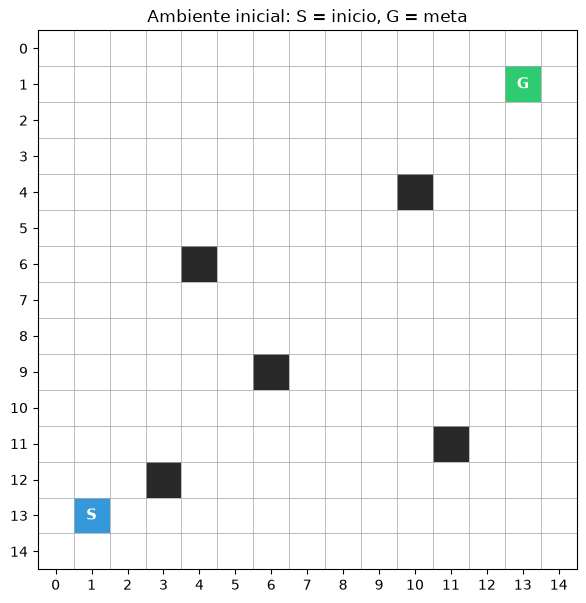

In [3]:
def draw_grid(env, ax=None, path=None, policy=None, values=None, title="GridWorld"):
    if ax is None:
        _, ax = plt.subplots(figsize=(7, 7))

    board = np.zeros((env.rows, env.cols))
    for obstacle in env.obstacles:
        board[obstacle] = 1
    board[env.start] = 2
    board[env.goal] = 3

    cmap = ListedColormap(["white", "#292929", "#3498db", "#2ecc71"])
    ax.imshow(board, cmap=cmap, vmin=0, vmax=3)

    ax.set_xticks(np.arange(-0.5, env.cols, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, env.rows, 1), minor=True)
    ax.grid(which="minor", color="#aaaaaa", linewidth=0.55)
    ax.tick_params(which="minor", bottom=False, left=False)
    ax.set_xticks(range(env.cols))
    ax.set_yticks(range(env.rows))

    if values is not None:
        finite = [values[s] for s in env.states() if s != env.goal]
        lo, hi = min(finite), max(finite)
        for s in env.states():
            if s not in (env.start, env.goal):
                shade = (values[s] - lo) / (hi - lo + 1e-12)
                ax.add_patch(plt.Rectangle(
                    (s[1] - 0.5, s[0] - 0.5), 1, 1,
                    color=plt.cm.YlOrRd(shade), alpha=0.32
                ))

    if policy is not None:
        for (r, c), arrow in policy.items():
            if (r, c) not in (env.start, env.goal):
                ax.text(c, r, arrow, ha="center", va="center", fontsize=8)

    if path:
        ys = [s[0] for s in path]
        xs = [s[1] for s in path]
        ax.plot(xs, ys, color="#e74c3c", linewidth=3, marker="o", markersize=3)

    ax.text(env.start[1], env.start[0], "S", ha="center", va="center",
            color="white", weight="bold", fontsize=11)
    ax.text(env.goal[1], env.goal[0], "G", ha="center", va="center",
            color="white", weight="bold", fontsize=11)
    ax.set_title(title)
    return ax


draw_grid(env, title="Ambiente inicial: S = inicio, G = meta")
plt.show()


## 4. Iteración de Valores

En cada iteración se actualizan **simultáneamente** todos los estados. Guardamos el historial completo para observar cómo la información de la recompensa se propaga desde la meta por el tablero.

El valor de una acción es:

$$Q(s,a)=r(s,a,s')+\gamma V(s')$$

y se conserva la acción con mayor valor.

In [4]:
def choose_direction(env, state, action_values):
    """Desempata acciones óptimas para formar rutas naturales tipo zigzag."""
    best_value = max(action_values.values())
    candidates = [a for a, value in action_values.items()
                  if np.isclose(value, best_value)]

    # Alternar la preferencia horizontal/vertical evita una ruta artificial
    # pegada a los bordes cuando varias rutas tienen exactamente igual valor.
    if (state[0] + state[1]) % 2 == 0:
        preference = ["→", "↑", "←", "↓"]
    else:
        preference = ["↑", "→", "↓", "←"]
    return next(action for action in preference if action in candidates)


def extract_policy(env, V):
    policy = {}
    for state in env.states():
        if env.is_terminal(state):
            continue
        action_values = {}
        for action in env.ACTIONS:
            next_state, reward = env.transition(state, action)
            action_values[action] = reward + env.gamma * V[next_state]
        policy[state] = choose_direction(env, state, action_values)
    return policy


def value_iteration(env, theta=1e-8, max_iterations=500):
    V = {state: 0.0 for state in env.states()}
    history = [V.copy()]
    deltas = []

    for iteration in range(1, max_iterations + 1):
        V_new = V.copy()
        delta = 0.0

        for state in env.states():
            if env.is_terminal(state):
                V_new[state] = 0.0
                continue

            action_values = []
            for action in env.ACTIONS:
                next_state, reward = env.transition(state, action)
                action_values.append(reward + env.gamma * V[next_state])

            V_new[state] = max(action_values)
            delta = max(delta, abs(V_new[state] - V[state]))

        V = V_new
        history.append(V.copy())
        deltas.append(delta)

        if delta < theta:
            break

    return V, extract_policy(env, V), history, deltas


V_opt, policy_opt, history, deltas = value_iteration(env)
print(f"Convergencia alcanzada en {len(deltas)} iteraciones")
print(f"Valor aprendido para el inicio: {V_opt[env.start]:.4f}")
print(f"Último cambio máximo (delta): {deltas[-1]:.2e}")


Convergencia alcanzada en 27 iteraciones
Valor aprendido para el inicio: 16.8828
Último cambio máximo (delta): 0.00e+00


## 5. Iteraciones: evidencia del proceso de aprendizaje

Cada panel muestra la política *greedy* disponible en ese momento. El fondo amarillo/rojo representa valores más altos. Al principio todas las acciones empatan; después, la recompensa de la meta se propaga gradualmente hasta el inicio.

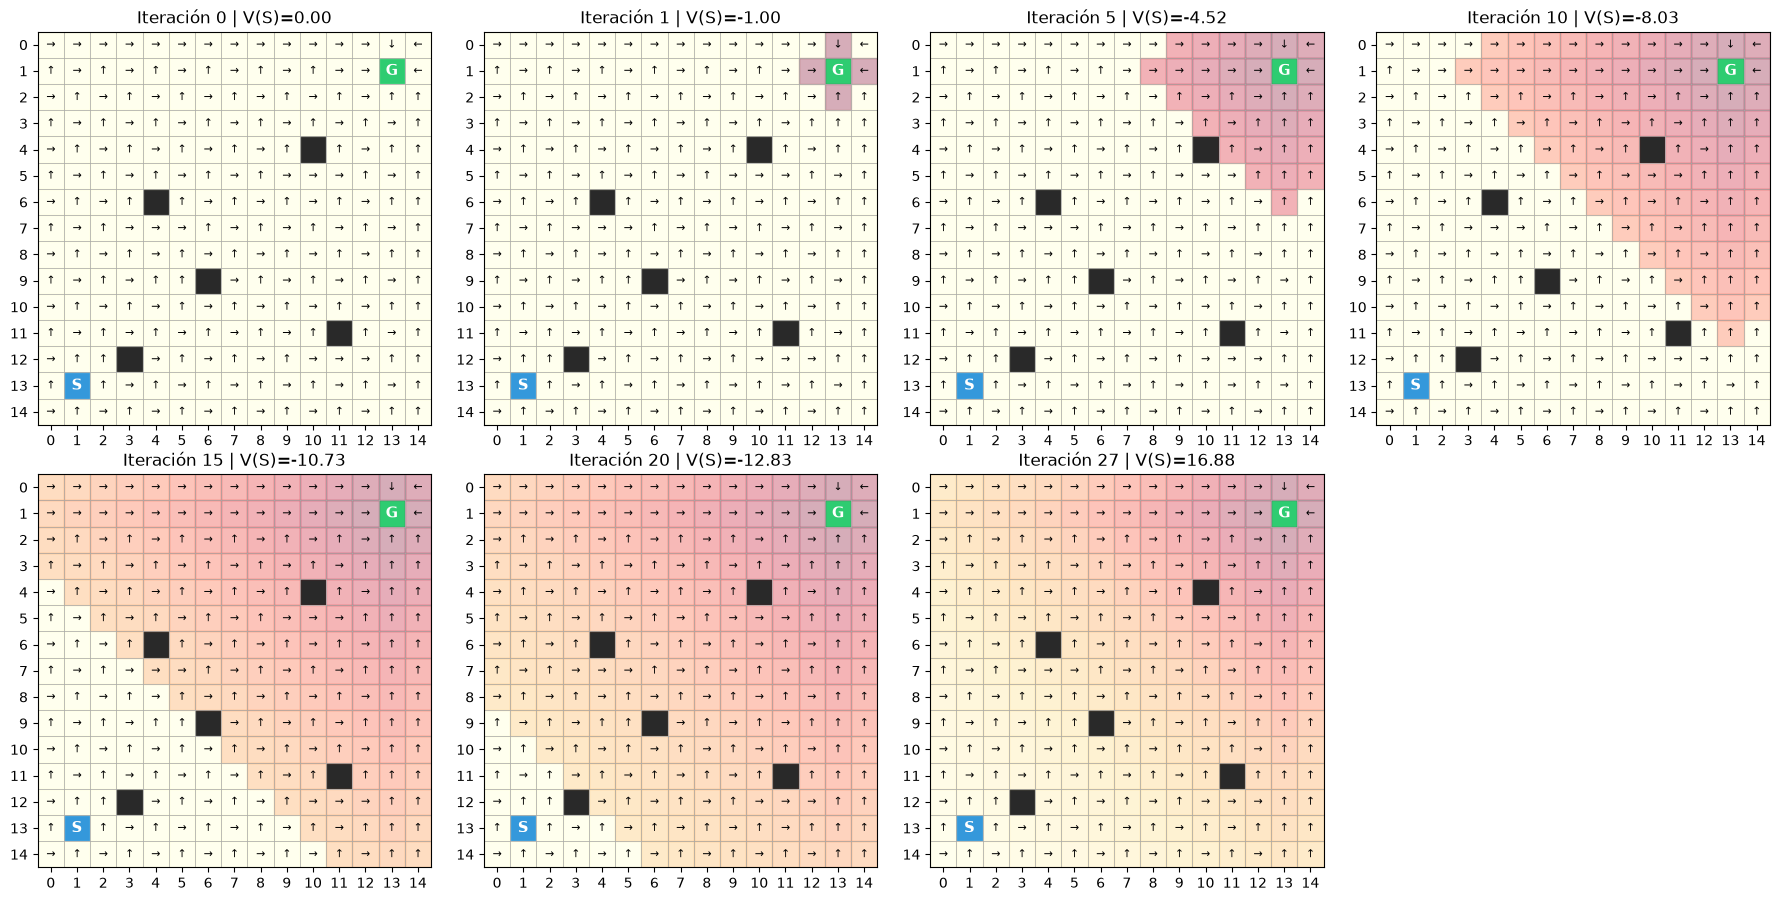

In [5]:
snapshots = [0, 1, 5, 10, 15, 20, len(history) - 1]
snapshots = list(dict.fromkeys(snapshots))

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.ravel()
for ax, k in zip(axes, snapshots):
    V_k = history[k]
    policy_k = extract_policy(env, V_k)
    draw_grid(env, ax=ax, policy=policy_k, values=V_k,
              title=f"Iteración {k} | V(S)={V_k[env.start]:.2f}")
for ax in axes[len(snapshots):]:
    ax.axis("off")
plt.tight_layout()
plt.show()


### Cambio máximo por iteración

El error de Bellman disminuye hasta ser menor que el umbral. Esta curva permite comprobar numéricamente la convergencia.

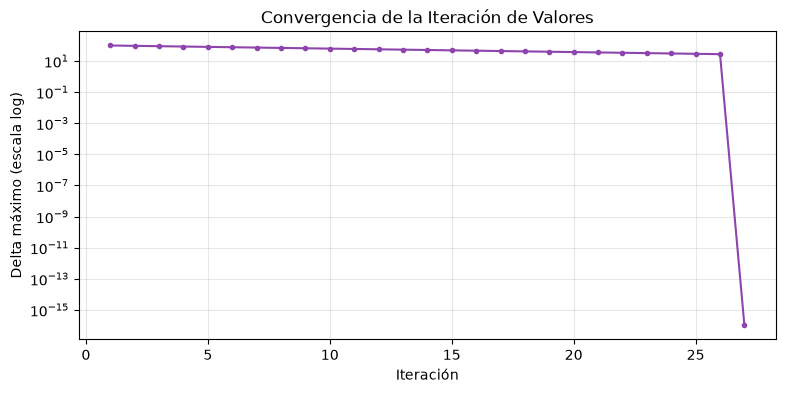

Resumen de iteraciones
Iteración   0: V(inicio)=   0.0000 | delta=—
Iteración   1: V(inicio)=  -1.0000 | delta=100
Iteración   5: V(inicio)=  -4.5244 | delta=81.4506
Iteración  10: V(inicio)=  -8.0253 | delta=63.0249
Iteración  15: V(inicio)= -10.7342 | delta=48.7675
Iteración  20: V(inicio)= -12.8303 | delta=37.7354
Iteración  27: V(inicio)=  16.8828 | delta=0


In [6]:
plt.figure(figsize=(9, 4))
plt.semilogy(range(1, len(deltas) + 1), np.maximum(deltas, 1e-16),
             color="#8e44ad", marker="o", markersize=3)
plt.xlabel("Iteración")
plt.ylabel("Delta máximo (escala log)")
plt.title("Convergencia de la Iteración de Valores")
plt.grid(alpha=0.3)
plt.show()

print("Resumen de iteraciones")
for k in snapshots:
    delta_text = "—" if k == 0 else f"{deltas[k-1]:.6g}"
    print(f"Iteración {k:>3}: V(inicio)={history[k][env.start]:>9.4f} | delta={delta_text}")


## 6. Trazar el mejor camino

Se sigue la política óptima desde `S` hasta `G`. Se incluye detección de ciclos como protección, aunque una política convergida debe alcanzar la meta.

Camino óptimo encontrado: 24 movimientos
Direcciones: → ↑ ↑ ↑ → ↑ → ↑ → ↑ → ↑ → ↑ → ↑ → ↑ → ↑ → ↑ → →
Estados recorridos:
[(13, 1), (13, 2), (12, 2), (11, 2), (10, 2), (10, 3), (9, 3), (9, 4), (8, 4), (8, 5), (7, 5), (7, 6), (6, 6), (6, 7), (5, 7), (5, 8), (4, 8), (4, 9), (3, 9), (3, 10), (2, 10), (2, 11), (1, 11), (1, 12), (1, 13)]


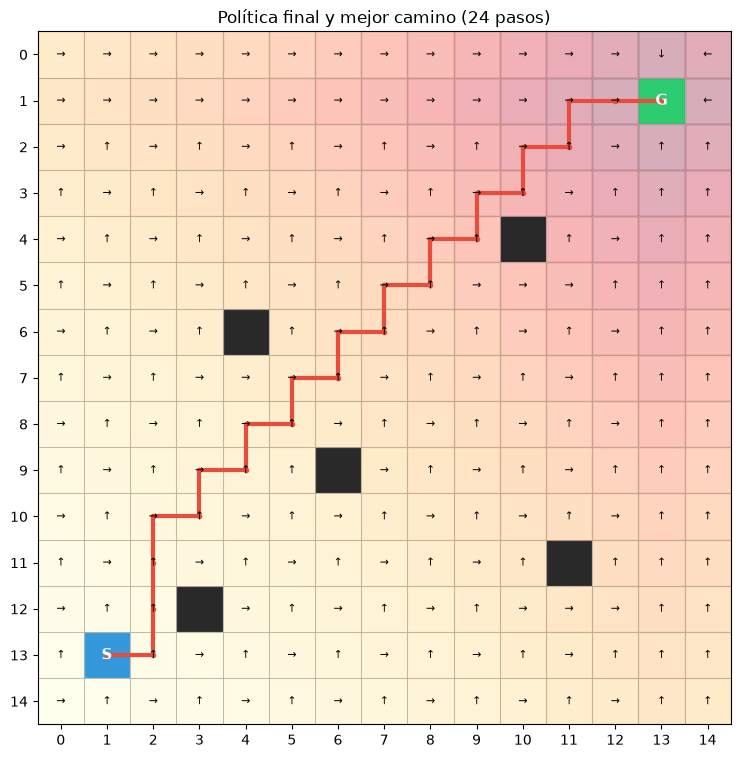

In [7]:
def trace_path(env, policy, max_steps=500):
    state = env.start
    path = [state]
    actions = []
    visited = {state}

    for _ in range(max_steps):
        if state == env.goal:
            return path, actions
        action = policy[state]
        next_state, _ = env.transition(state, action)
        actions.append(action)
        path.append(next_state)
        if next_state in visited and next_state != env.goal:
            raise RuntimeError(f"La política produjo un ciclo en {next_state}")
        visited.add(next_state)
        state = next_state

    raise RuntimeError("No se alcanzó la meta dentro del límite de pasos")


best_path, best_actions = trace_path(env, policy_opt)
print(f"Camino óptimo encontrado: {len(best_actions)} movimientos")
print("Direcciones:", " ".join(best_actions))
print("Estados recorridos:")
print(best_path)

fig, ax = plt.subplots(figsize=(9, 9))
draw_grid(env, ax=ax, path=best_path, policy=policy_opt, values=V_opt,
          title=f"Política final y mejor camino ({len(best_actions)} pasos)")
plt.show()


## 7. Cómo mejora la ruta durante el aprendizaje

Antes de que el valor de la meta alcance el inicio, la política puede quedar atrapada por empates. Por eso se muestra si la política parcial ya consigue llegar a la meta y cuántos pasos necesita.

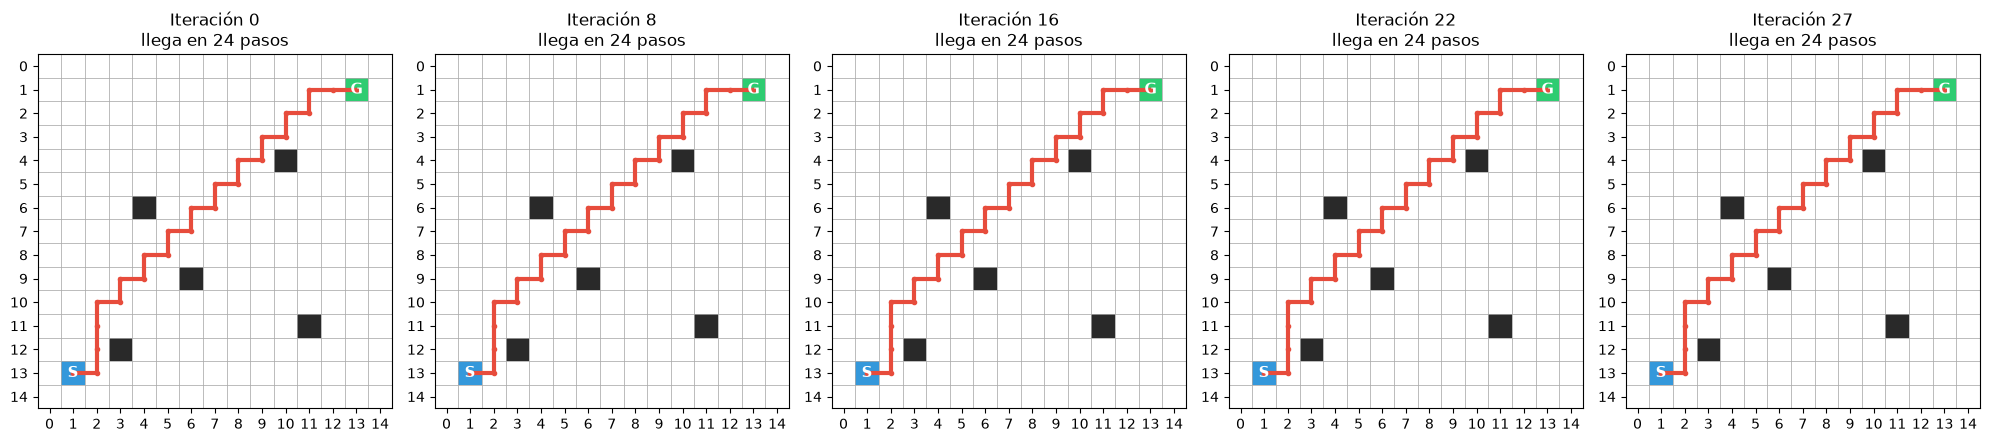

In [8]:
def safe_path(env, V, max_steps=300):
    policy = extract_policy(env, V)
    state = env.start
    path = [state]
    visited = {state}
    for _ in range(max_steps):
        if state == env.goal:
            return path, True
        next_state, _ = env.transition(state, policy[state])
        path.append(next_state)
        if next_state in visited:
            return path, False
        visited.add(next_state)
        state = next_state
    return path, False


route_iterations = [0, 8, 16, 22, len(history)-1]
route_iterations = list(dict.fromkeys(route_iterations))
fig, axes = plt.subplots(1, len(route_iterations), figsize=(4 * len(route_iterations), 4.5))
axes = np.atleast_1d(axes)

for ax, k in zip(axes, route_iterations):
    partial_path, reached = safe_path(env, history[k])
    status = f"llega en {len(partial_path)-1} pasos" if reached else "aún no llega"
    draw_grid(env, ax=ax, path=partial_path, title=f"Iteración {k}\n{status}")

plt.tight_layout()
plt.show()


## 8. Resolver el mismo GridWorld con Q-Learning

Ahora el agente **no recibe la solución ni los valores del tablero**. Aprende recorriendo el ambiente mediante episodios y actualizando una tabla $Q(s,a)$:

$$Q(s,a) \leftarrow Q(s,a)+\alpha\left[r+\gamma\max_{a'}Q(s',a')-Q(s,a)\right]$$

La selección de acciones es $\epsilon$-greedy: al principio explora mucho y gradualmente utiliza lo aprendido. Se conserva la misma recompensa y el mismo factor de descuento usados en Iteración de Valores para que la comparación sea justa.

In [9]:
class QLearningAgent:
    def __init__(self, env, alpha=0.15, epsilon=1.0,
                 epsilon_min=0.03, epsilon_decay=0.9975, seed=42):
        self.env = env
        self.alpha = alpha
        self.gamma = env.gamma
        self.epsilon = epsilon
        self.epsilon_min = epsilon_min
        self.epsilon_decay = epsilon_decay
        self.rng = np.random.default_rng(seed)
        self.Q = {
            state: {action: 0.0 for action in env.ACTIONS}
            for state in env.states()
        }

    def choose_action(self, state, training=True):
        if training and self.rng.random() < self.epsilon:
            return self.rng.choice(list(self.env.ACTIONS))
        return choose_direction(self.env, state, self.Q[state])

    def update(self, state, action, reward, next_state):
        current_q = self.Q[state][action]
        if self.env.is_terminal(next_state):
            target = reward
        else:
            target = reward + self.gamma * max(self.Q[next_state].values())
        self.Q[state][action] += self.alpha * (target - current_q)

    def decay_exploration(self):
        self.epsilon = max(self.epsilon_min,
                           self.epsilon * self.epsilon_decay)


### Entrenamiento por episodios

Cada episodio comienza nuevamente en `S`. Se registra la recompensa, la cantidad de movimientos y si el agente alcanzó la meta. Todos los episodios tienen un límite para garantizar que ninguna ejecución pueda quedar en un ciclo infinito.

In [10]:
def train_q_learning(env, agent, episodes=5000, max_steps=250):
    rewards = []
    steps_history = []
    successes = []

    for episode in range(1, episodes + 1):
        state = env.start
        total_reward = 0.0
        reached_goal = False

        for step in range(1, max_steps + 1):
            action = agent.choose_action(state, training=True)
            next_state, reward = env.transition(state, action)
            agent.update(state, action, reward, next_state)
            total_reward += reward
            state = next_state

            if env.is_terminal(state):
                reached_goal = True
                break

        rewards.append(total_reward)
        steps_history.append(step)
        successes.append(int(reached_goal))
        agent.decay_exploration()

        if episode in [1, 100, 500, 1000, 2500, episodes]:
            recent_success = np.mean(successes[-100:]) * 100
            print(f"Episodio {episode:4d} | epsilon={agent.epsilon:.3f} "
                  f"| recompensa={total_reward:7.1f} | pasos={step:3d} "
                  f"| éxito reciente={recent_success:5.1f}%")

    return rewards, steps_history, successes


q_agent = QLearningAgent(env)
q_rewards, q_steps, q_successes = train_q_learning(env, q_agent)


Episodio    1 | epsilon=0.998 | recompensa= -326.0 | pasos=250 | éxito reciente=  0.0%
Episodio  100 | epsilon=0.779 | recompensa=  -10.0 | pasos= 75 | éxito reciente= 36.0%
Episodio  500 | epsilon=0.286 | recompensa=   69.0 | pasos= 32 | éxito reciente=100.0%
Episodio 1000 | epsilon=0.082 | recompensa=   77.0 | pasos= 24 | éxito reciente=100.0%
Episodio 2500 | epsilon=0.030 | recompensa=   77.0 | pasos= 24 | éxito reciente=100.0%
Episodio 5000 | epsilon=0.030 | recompensa=   77.0 | pasos= 24 | éxito reciente=100.0%


### Evidencia del aprendizaje de Q-Learning

Se usa un promedio móvil de 100 episodios para distinguir la tendencia general del ruido producido por la exploración.

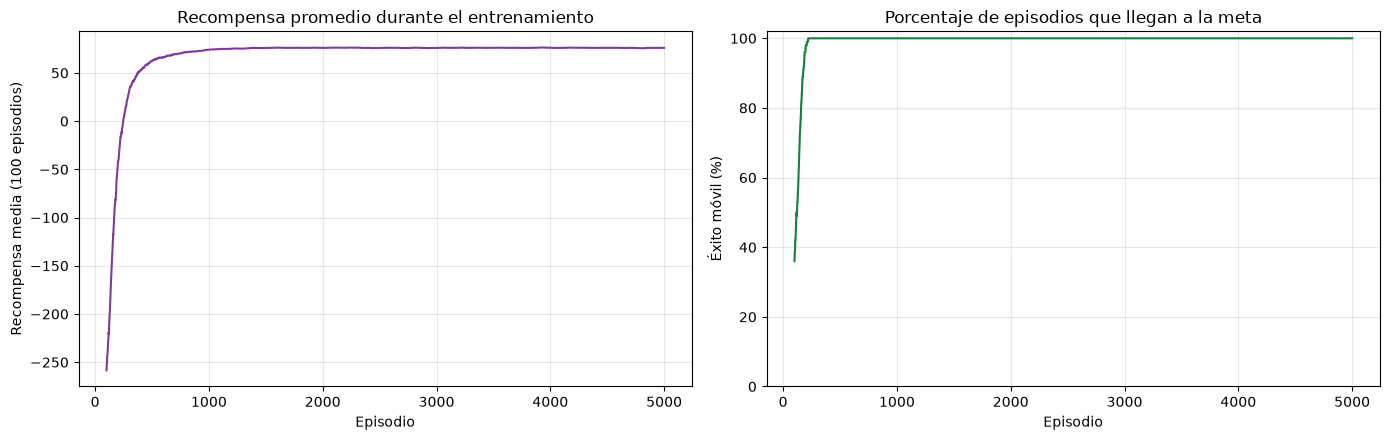

In [11]:
window = 100
episodes_axis = np.arange(window, len(q_rewards) + 1)
reward_average = np.convolve(q_rewards, np.ones(window) / window, mode="valid")
success_average = np.convolve(q_successes, np.ones(window) / window, mode="valid")

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
axes[0].plot(episodes_axis, reward_average, color="#7d3c98")
axes[0].set_title("Recompensa promedio durante el entrenamiento")
axes[0].set_xlabel("Episodio")
axes[0].set_ylabel("Recompensa media (100 episodios)")
axes[0].grid(alpha=0.3)

axes[1].plot(episodes_axis, success_average * 100, color="#16803c")
axes[1].set_title("Porcentaje de episodios que llegan a la meta")
axes[1].set_xlabel("Episodio")
axes[1].set_ylabel("Éxito móvil (%)")
axes[1].set_ylim(0, 102)
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 9. Política aprendida y comparación final

Se desactiva la exploración y se sigue únicamente la mejor acción aprendida. Luego se compara con la solución exacta de Iteración de Valores.

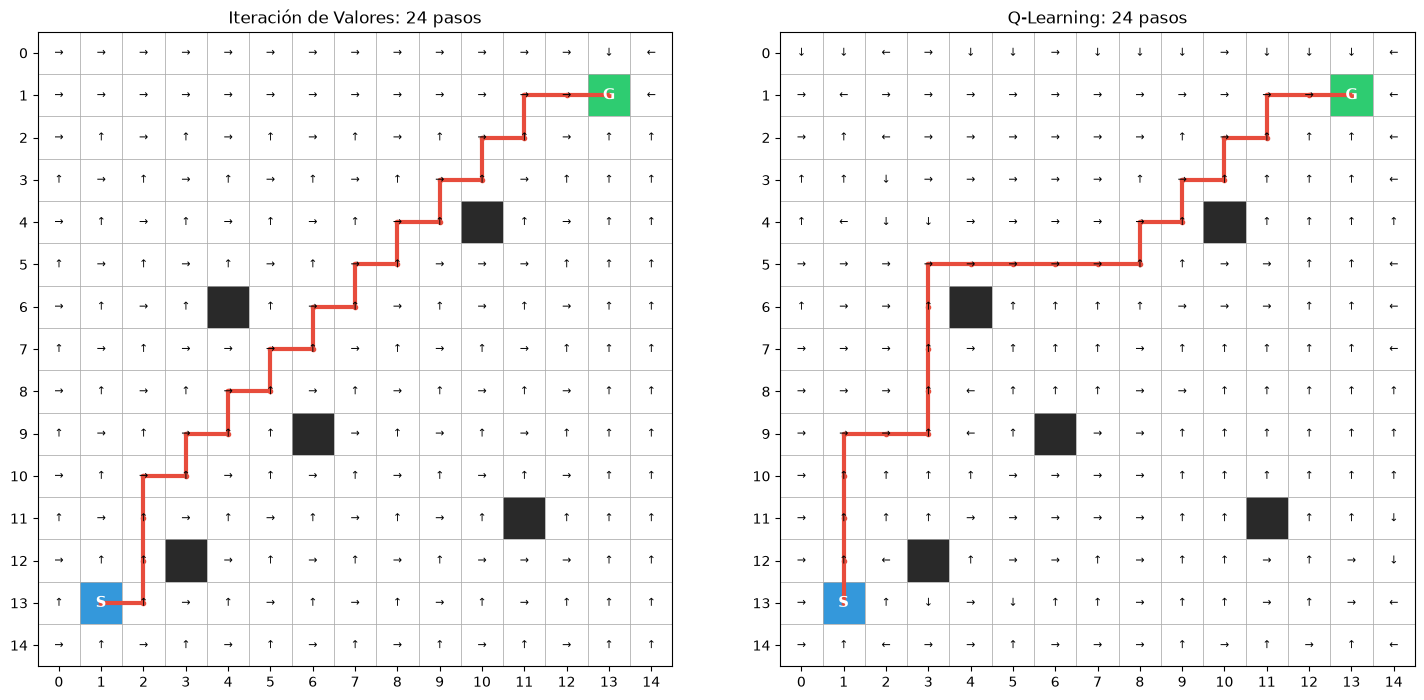

COMPARACIÓN DE RESULTADOS
--------------------------------------------------------------
Criterio                   Iteración de Valores  Q-Learning
--------------------------------------------------------------
Usa modelo del ambiente    Sí                    No
Unidad de aprendizaje      27 iteraciones        5000 episodios
Pasos de la ruta final     24                    24
Llegó a la meta            Sí                    Sí
Ruta igual de corta        Referencia óptima     Sí

Direcciones con Iteración de Valores:
→ ↑ ↑ ↑ → ↑ → ↑ → ↑ → ↑ → ↑ → ↑ → ↑ → ↑ → ↑ → →

Direcciones aprendidas con Q-Learning:
↑ ↑ ↑ ↑ → → ↑ ↑ ↑ ↑ → → → → → ↑ → ↑ → ↑ → ↑ → →


In [12]:
q_policy = {
    state: choose_direction(env, state, action_values)
    for state, action_values in q_agent.Q.items()
    if not env.is_terminal(state)
}

q_path, q_actions = trace_path(env, q_policy)

fig, axes = plt.subplots(1, 2, figsize=(15, 7))
draw_grid(env, ax=axes[0], path=best_path, policy=policy_opt,
          title=f"Iteración de Valores: {len(best_actions)} pasos")
draw_grid(env, ax=axes[1], path=q_path, policy=q_policy,
          title=f"Q-Learning: {len(q_actions)} pasos")
plt.tight_layout()
plt.show()

print("COMPARACIÓN DE RESULTADOS")
print("-" * 62)
print(f"{'Criterio':<27}{'Iteración de Valores':<22}{'Q-Learning'}")
print("-" * 62)
print(f"{'Usa modelo del ambiente':<27}{'Sí':<22}{'No'}")
print(f"{'Unidad de aprendizaje':<27}{str(len(deltas)) + ' iteraciones':<22}{str(len(q_rewards)) + ' episodios'}")
print(f"{'Pasos de la ruta final':<27}{len(best_actions):<22}{len(q_actions)}")
print(f"{'Llegó a la meta':<27}{'Sí':<22}{'Sí' if q_path[-1] == env.goal else 'No'}")
print(f"{'Ruta igual de corta':<27}{'Referencia óptima':<22}{'Sí' if len(q_actions) == len(best_actions) else 'No'}")

print("\nDirecciones con Iteración de Valores:")
print(" ".join(best_actions))
print("\nDirecciones aprendidas con Q-Learning:")
print(" ".join(q_actions))


## 10. Conclusiones

1. Los cinco obstáculos son casillas individuales, aisladas y distribuidas sin formar muros ni una diagonal regular.
2. **Iteración de Valores** conoce todas las transiciones y converge rápidamente a una solución exacta mediante Bellman.
3. **Q-Learning** no conoce el modelo: necesita explorar durante miles de episodios y aprende solamente de las recompensas observadas.
4. Ambos métodos usan el mismo ambiente, recompensas y $\gamma$, por lo que la longitud de sus rutas finales se puede comparar directamente.
5. Si Q-Learning obtiene el mismo número de pasos que Iteración de Valores, encontró una política igualmente óptima aunque su recorrido concreto pueda diferir por empates entre rutas.
6. Las curvas de recompensa y éxito evidencian cómo Q-Learning pasa de movimientos casi aleatorios a alcanzar consistentemente la meta.